# Manifold learning (_S-Curve_)

In [1]:
from experiments.utils.constants import RANDOM_SEED, SOM_LEARNING_RATE_DECAY_FN, SOM_FIT_METHOD

VERBOSE = True
MANIFOLD_NAME = "S-Curve"
MODELING_MODE = True
MODEL_REGISTRATION_MODE = False

from experiments.utils.data_manifold import generate_s_curve
MANIFOLD_GENERATOR = generate_s_curve

## Dataset

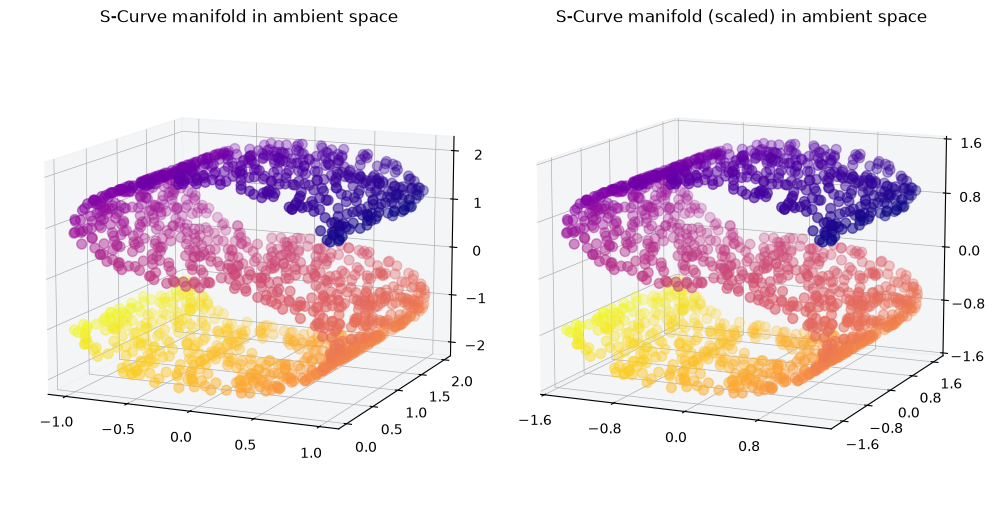

In [2]:
# generate data
from experiments.utils.plotting import visualize_manifold
X, y = MANIFOLD_GENERATOR()

# visualize 1/2
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 10))
ax0 = fig.add_subplot(121, projection="3d")
visualize_manifold(X, y, title=f"{MANIFOLD_NAME} manifold in ambient space", ax=ax0, hold_on=True);

# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
del X

# visualize 2/2
ax1 = fig.add_subplot(122, projection="3d")
visualize_manifold(X_scaled, y, title=f"{MANIFOLD_NAME} manifold (scaled) in ambient space", ax=ax1, hold_on=False);

## Modeling

In [3]:
from minisom_representation import calc_som_hyparams, SomRepresentation, plot_som_convergence_over_epochs

In [4]:
# use helper methods to get SOM hyperparameter recommendations
recommended_params = calc_som_hyparams(X_scaled, initial_sigma_factor=3.0)
print("Recommended SOM parameters:", recommended_params)

Recommended SOM parameters: {'d1': 14, 'd2': 15, 'sigma': 5.0}


In [5]:
# define actual hyperparameters
d1, d2, sigma = map(recommended_params.get, ("d1", "d2", "sigma"))
decay_function = SOM_LEARNING_RATE_DECAY_FN
epoch = None

Evaluating for epochs of [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]...
Training SOM for 1 epochs...
Training SOM for 2 epochs...
Training SOM for 3 epochs...
Training SOM for 4 epochs...
Training SOM for 5 epochs...
Training SOM for 6 epochs...
Training SOM for 7 epochs...
Training SOM for 8 epochs...
Training SOM for 9 epochs...
Training SOM for 10 epochs...
Training SOM for 11 epochs...
Training SOM for 12 epochs...
Training SOM for 13 epochs...
Training SOM for 14 epochs...
Training SOM for 15 epochs...
Training SOM for 16 epochs...
Training SOM for 17 epochs...
Training SOM for 18 epochs...
Training SOM for 19 epochs...
Training SOM for 20 epochs...
Training SOM for 21 epochs...
Training SOM for 22 epochs...
Training SOM for 23 epochs...
Training SOM for 24 epochs...
Training SOM for 25 epochs...
Training SOM for 26 epochs...
Training SOM for 27 epochs...
Training SOM for 

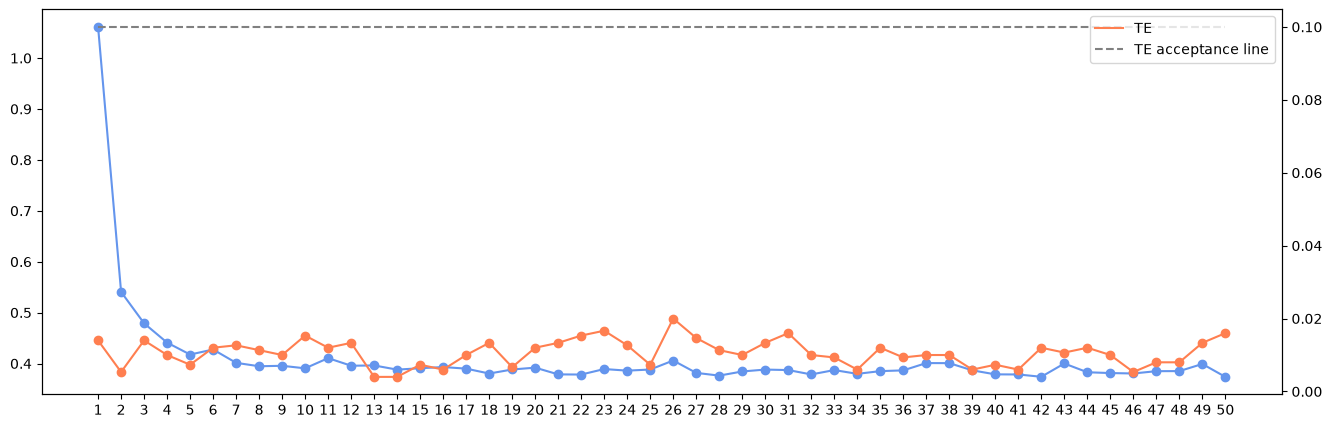


QE (first -> last): 	 1.06 -> 0.37
TE (first -> last): 	 0.01 -> 0.02


In [6]:
# test candidate values for `num_iteration` hyperparameter
if MODELING_MODE:
    fig, errors_qe, errors_te = plot_som_convergence_over_epochs(
        SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=False, decay_function=decay_function),
        X_scaled,
        fit_type=SOM_FIT_METHOD, te_ceiling=.1,
        epoch_step_from=2, epoch_step_to=50, epoch_step=1,
        figsize=(16, 5), show_fig=True, verbose=VERBOSE
    )
    print(f"\nQE (first -> last): \t {errors_qe[0]:.2f} -> {errors_qe[-1]:.2f}")
    print(f"TE (first -> last): \t {errors_te[0]:.2f} -> {errors_te[-1]:.2f}")
else: print("Skipping model candidate parameters evaluation.")

In [7]:
# set selected `num_iteration` as epoch
epoch = 46

In [8]:
# fit SOM representation
som_rep = SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=VERBOSE, decay_function=decay_function) \
    .fit_online(X_scaled, num_iteration=epoch)

 [ 69000 / 69000 ] 100% - 0:00:00 left 
 quantization error: 0.38042463645640007

 An SOM representation has been fitted as follows:
------------------------------------------------------- 

Fit strategy: online 

Hyperparameters of SOM: 

{'input_len': 3, 'x': 14, 'y': 15, 'sigma': 5.0, 'topology': 'rectangular', 'learning_rate': 0.5, 'decay_function': 'linear_decay_to_zero', 'sigma_decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'activation_distance': 'euclidean', 'random_seed': 42, 'num_iteration': 46, 'use_epochs': True, 'random_order': True, 'verbose': True} 

Quality of SOM: 

Quantization Error (QE):	0.38042463645640007
Topographic Error (TE): 	0.005333333333333333


## Direct inspection of the fitted representation model

In [9]:
# extract SOM prototype weights
som = som_rep.som
node_weights = som.get_weights()
node_weights_flat = node_weights.reshape(-1, node_weights.shape[2])

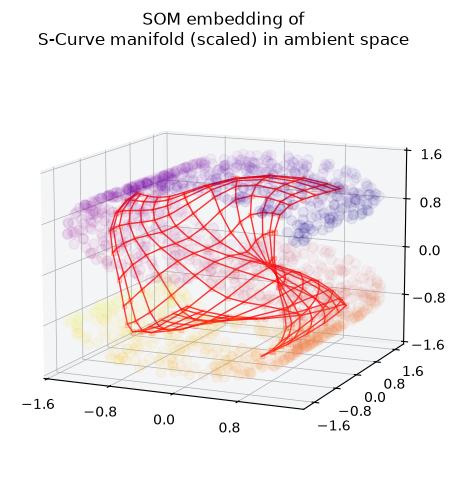

In [10]:
from utils.plotting import place_som_lattice
data_plot_style = { "alpha": 0.3 }
fig, ax = visualize_manifold(X_scaled, y, f"SOM embedding of\n{MANIFOLD_NAME} manifold (scaled) in ambient space", plot_style_args=data_plot_style, hold_on=True)
place_som_lattice(ax, node_weights, node_weights_flat)

## Inspection of the learned 2D topology

In [11]:
# create Basin
from lilypond import Basin
basin = Basin.from_som_representation(som_rep, random_seed=RANDOM_SEED, verbose=VERBOSE)

In [12]:
# traditional visuals
basin.legacy_pond().visualize_distance_map();
basin.legacy_pond().visualize_activation_map();

In [13]:
# lilypond visual
basin.pond() \
    .rhizome_layer() \
    .pad_layer(gap="nogap") \
    .petal_layer(min_size=3, max_size=20) \
    .visualize(width=800, height=600);

## Detailed inspection

In [14]:
basin.pond() \
    .pad_layer() \
    .visualize(width=800, height=600);

In [15]:
basin.pond() \
    .pad_layer(gap="nogap") \
    .petal_layer() \
    .visualize(width=800, height=600);

In [16]:
basin.pond() \
    .pad_layer(gap="nogap") \
    .attraction_layer(X_scaled, marker=dict(color=y, colorscale="plasma", symbol="triangle-up", opacity=.8), name="Projection of training data colored by Manifold position") \
    .visualize(width=1000, height=600);

In [17]:
basin.pond() \
    .pad_layer(gap="nogap") \
    .rhizome_layer(max_width=30) \
    .attraction_layer(X_scaled, marker=dict(color=y, colorscale="plasma", symbol="triangle-up", opacity=.8), name="Projection of training data colored by Manifold position") \
    .visualize(width=1000, height=600);

In [18]:
basin.pond() \
    .pad_layer(gap="nogap") \
    .rhizome_layer(violations_only=True) \
    .attraction_layer(X_scaled, marker=dict(color=y, colorscale="plasma", symbol="triangle-up", opacity=.95), name="Projection of training data colored by Manifold position") \
    .visualize(width=1000, height=600);

---

### The below cells are not part of the experiment. They are used to register the model in Databricks and Bianor for further interactive investigation.

---

In [ ]:
# TODO: The above model is not yet registered -> register as a new version.

## Register representation model in Databricks

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
CATALOG = "workspace"
SCHEMA = "lilypond_experiments"
MODEL_NAME = "som-scurve"
MODEL_PATH = f"{CATALOG}.{SCHEMA}.{MODEL_NAME}"
MODEL_PATH

In [ ]:
import mlflow
import pandas as pd
from typing import Any

EXPERIMENT_NAME = "/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_SCurve"
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

class MLflowSomModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model:SomRepresentation, scaler):
        self.model = model
        self.scaler = scaler
    def predict(self, context, model_input, params: dict[str, Any] | None = None):
        """First transforms the input data via scaler, then predicts the winner node of the SOM."""
        return [self.model.som.winner(x) for x in self.scaler.transform(model_input.to_numpy())]

if MODEL_REGISTRATION_MODE:
    with mlflow.start_run():
        model = MLflowSomModelWrapper(som_rep, scaler)

        mlflow.log_metric("QE", som_rep.quantization_error)
        mlflow.log_metric("TE", som_rep.topographic_error)

        mlflow.pyfunc.log_model(
            python_model=model,
            name=MODEL_NAME,
            input_example=pd.DataFrame(X_scaled[:3]),
            pip_requirements=[
                "numpy",
                "pandas",
                "scikit-learn==1.5.2",
                "mlflow",
                "minisom",
            ],
            registered_model_name=MODEL_PATH
        )
else: print("Skipping MLflow model registration.")

In [ ]:
version = 1
registered_model = f"{MODEL_NAME}/{version}"
registered_model

## Register metadata in Bianor

In [ ]:
from databricks.connect import DatabricksSession
spark = DatabricksSession.builder.getOrCreate()

In [ ]:
from bianor_databricks_kit import BianorRecordManager
bianor_recorder = BianorRecordManager(catalog=CATALOG, schema=SCHEMA, spark=spark)

In [ ]:
registered_model_location = f"{CATALOG}.{SCHEMA}.{registered_model}"
registered_model_location

In [ ]:
if MODEL_REGISTRATION_MODE:
    bianor_recorder.new_representation(name=f"{MANIFOLD_NAME} Manifold", som_model_location=registered_model_location, features_location="c.s.t") # FIXME
else: print("Skipping Bianor metadata registration.")